In [1]:
import json
import re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1 Percent Bins - Split by Questions vs. Just Tokens

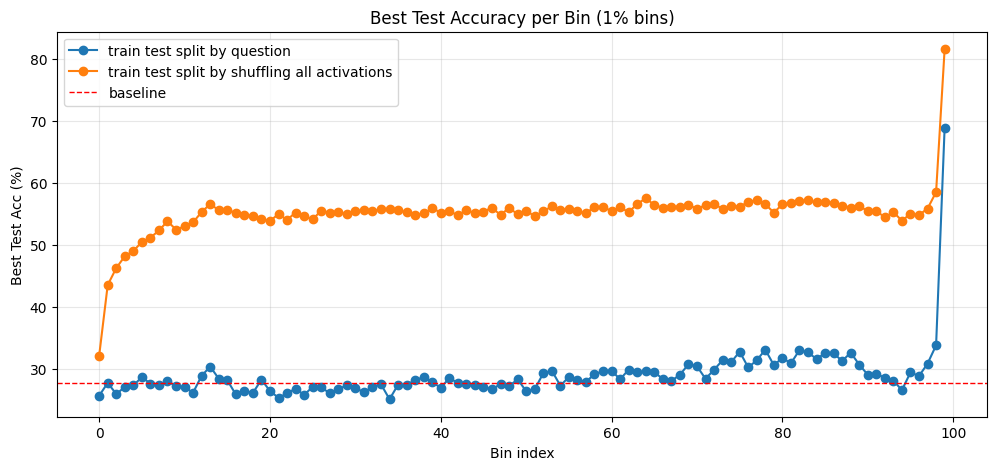

In [ ]:


# Paths
BASE = Path('..') / 'results'
Q_PATH = BASE / 'last_layer_1_percent_bin_sweep_question/' / 'results.jsonl'
T_PATH = BASE / 'last_layer_1_percent_bin_sweep' / 'results.jsonl'

# Helper to load best per bin
BIN_RE = re.compile(r"bin_(\d+)_experiment")

def load_best(path: Path) -> pd.DataFrame:
    records = []
    if not path.exists():
        return pd.DataFrame(columns=['bin_idx', 'test_acc'])
    with open(path, 'r') as f:
        for line in f:
            try:
                rec = json.loads(line)
            except json.JSONDecodeError:
                continue
            if str(rec.get('epoch')) != 'best':
                continue
            run = rec.get('run_name', '')
            m = BIN_RE.search(run)
            if not m:
                continue
            bin_idx = int(m.group(1))
            records.append({'bin_idx': bin_idx, 'test_acc': rec.get('test_acc')})
    df = pd.DataFrame(records)
    return df.sort_values('bin_idx')

# Load
q_df = load_best(Q_PATH)
t_df = load_best(T_PATH)

# Plot
plt.figure(figsize=(12, 5))
if not q_df.empty:
    plt.plot(q_df['bin_idx'], q_df['test_acc'], marker='o', label='train test split by question')
if not t_df.empty:
    plt.plot(t_df['bin_idx'], t_df['test_acc'], marker='o', label='train test split by shuffling all activations')
# Baseline line
plt.axhline(y=27.8, color='red', linestyle='--', linewidth=1, label='baseline')
plt.title('Probes Trained on Bins of 1% Seq Len (From Only Last Layer)')
plt.xlabel('Bin index')
plt.ylabel('Best Test Acc (%)')
plt.grid(True, alpha=0.3)

plt.legend()
plt.show()


# Single Position Probes From Back

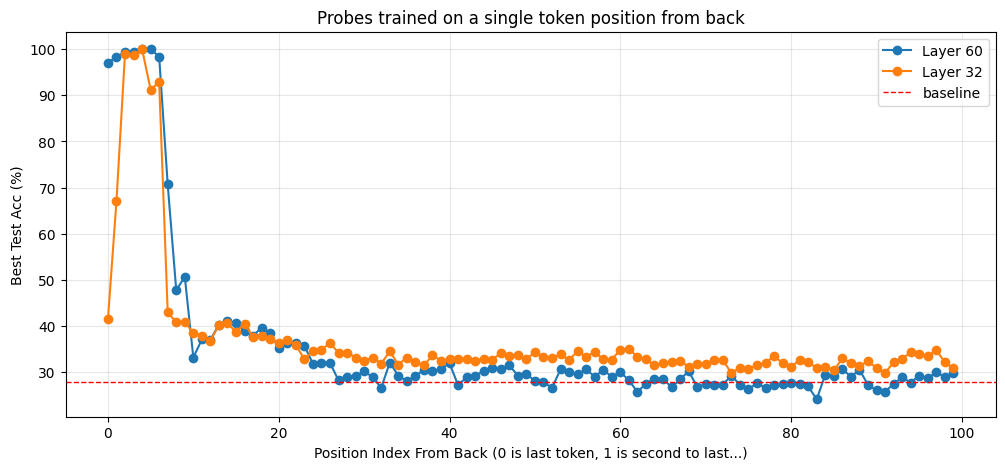

In [3]:
# Paths
BASE = Path('..') / 'results'
LAST_LAYER_PATH = BASE / 'last_layer_absolute_pos_back_sweep/' / 'results.jsonl'
LAYER32_PATH = BASE / 'last_100_positions_layer32/' / 'results.jsonl'

# Helper to load best per bin
BIN_RE = re.compile(r"bin_(\d+)_experiment")

def load_best(path: Path) -> pd.DataFrame:
    records = []
    if not path.exists():
        return pd.DataFrame(columns=['bin_idx', 'test_acc'])
    with open(path, 'r') as f:
        for line in f:
            try:
                rec = json.loads(line)
            except json.JSONDecodeError:
                continue
            if str(rec.get('epoch')) != 'best':
                continue
            run = rec.get('run_name', '')
            m = BIN_RE.search(run)
            if not m:
                continue
            bin_idx = int(m.group(1))
            records.append({'bin_idx': bin_idx, 'test_acc': rec.get('test_acc')})
    df = pd.DataFrame(records)
    return df.sort_values('bin_idx')

# Load
last_layer_df = load_best(LAST_LAYER_PATH)
layer32_df = load_best(LAYER32_PATH)
# Plot
plt.figure(figsize=(12, 5))
if not last_layer_df.empty:
    plt.plot(last_layer_df['bin_idx'], last_layer_df['test_acc'], marker='o', label='Layer 60')
if not layer32_df.empty:
    plt.plot(layer32_df['bin_idx'], layer32_df['test_acc'], marker='o', label='Layer 32')
# Baseline line
plt.axhline(y=27.8, color='red', linestyle='--', linewidth=1, label='baseline')
plt.title('Probes trained on a single token position from back')
plt.xlabel('Position Index From Back (0 is last token, 1 is second to last...)')
plt.ylabel('Best Test Acc (%)')
plt.grid(True, alpha=0.3)

plt.legend()
plt.show()


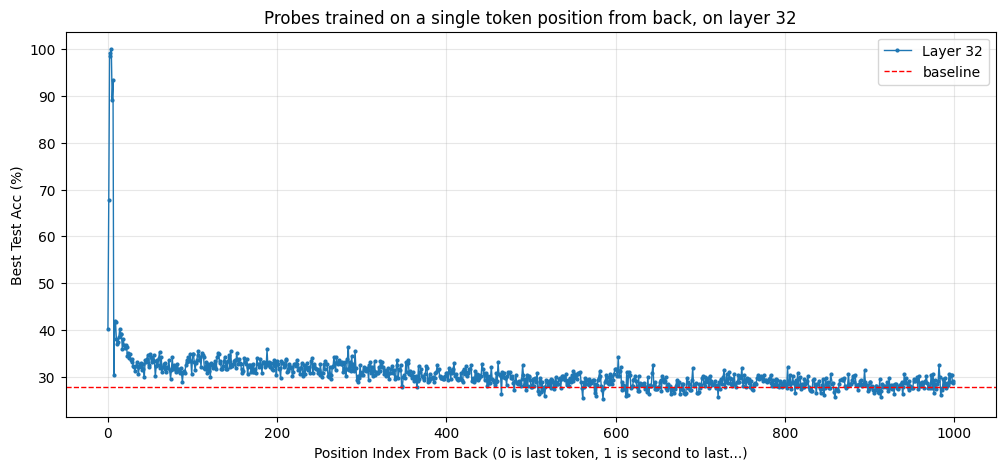

In [18]:
# Paths
BASE = Path('..') / 'results'
LAST_LAYER_PATH = BASE / 'linear_last_1k_positions/' / 'results.jsonl'

# Helper to load best per bin
BIN_RE = re.compile(r"bin_(\d+)_experiment")

def load_best(path: Path) -> pd.DataFrame:
    records = []
    if not path.exists():
        return pd.DataFrame(columns=['bin_idx', 'test_acc'])
    with open(path, 'r') as f:
        for line in f:
            try:
                rec = json.loads(line)
            except json.JSONDecodeError:
                continue
            if str(rec.get('epoch')) != 'best':
                continue
            run = rec.get('run_name', '')
            m = BIN_RE.search(run)
            if not m:
                continue
            bin_idx = int(m.group(1))
            records.append({'bin_idx': bin_idx, 'test_acc': rec.get('test_acc')})
    df = pd.DataFrame(records)
    return df.sort_values('bin_idx')

# Load
last_layer_df = load_best(LAST_LAYER_PATH)
# Plot
plt.figure(figsize=(12, 5))
if not last_layer_df.empty:
    plt.plot(last_layer_df['bin_idx'], last_layer_df['test_acc'], marker='o', label='Layer 32', linewidth=1, markersize=2)
# Baseline line
plt.axhline(y=27.8, color='red', linestyle='--', linewidth=1, label='baseline')
plt.title('Probes trained on a single token position from back, on layer 32')
plt.xlabel('Position Index From Back (0 is last token, 1 is second to last...)')
plt.ylabel('Best Test Acc (%)')
plt.grid(True, alpha=0.3)

plt.legend()
plt.show()


# Layerwise Probes Trained on All Positions


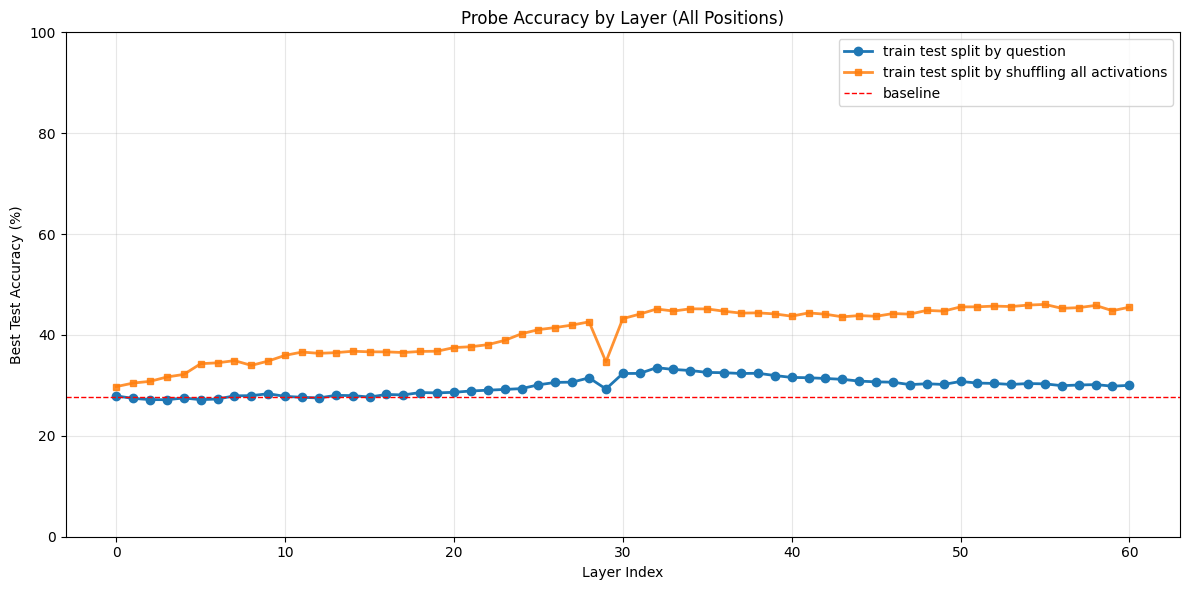

Layer sweep (all_positions_probe) summary:
  Total layers tested: 61
  Best accuracy: 33.52%
  Best layer: 32
  Mean accuracy: 29.85%
  Std accuracy: 1.78%
Layer sweep (layerwise_v2) summary:
  Total layers tested: 61
  Best accuracy: 46.06%
  Best layer: 55
  Mean accuracy: 40.57%
  Std accuracy: 4.91%


In [17]:
def load_layer_sweep(results_path):
    records = []
    if os.path.exists(results_path):
        with open(results_path, 'r') as f:
            for line in f:
                rec = json.loads(line.strip())
                if 'layer_' in rec.get('run_name', '') and rec.get('epoch') == 'best':
                    m = re.search(r'layer_(\d+)_experiment', rec.get('run_name', ''))
                    if m:
                        layer_idx = int(m.group(1))
                        records.append({'layer_idx': layer_idx, 'test_acc': rec.get('test_acc')})
    df = pd.DataFrame(records)
    if not df.empty:
        return df.sort_values('layer_idx')
    else:
        return df

def load_layer_sweep_v2(results_path):
    # v2 format: each line has keys like {"run_name": "layerwise_v2", "layer_idx": int, "best_test_acc": float}
    records = []
    if os.path.exists(results_path):
        with open(results_path, 'r') as f:
            for line in f:
                try:
                    rec = json.loads(line.strip())
                except json.JSONDecodeError:
                    continue
                if rec.get('layer_idx') is None:
                    continue
                layer_idx = int(rec['layer_idx'])
                # Prefer best_test_acc if present; fall back to detailed_eval_acc if needed
                acc = rec.get('best_test_acc')
                if acc is None:
                    acc = rec.get('detailed_eval_acc')
                if acc is None:
                    continue
                records.append({'layer_idx': layer_idx, 'test_acc': acc})
    df = pd.DataFrame(records)
    if not df.empty:
        return df.sort_values('layer_idx')
    else:
        return df

BASE = Path('..') / 'results'
LAYER_SWEEP_PATH = BASE / 'all_positions_probe/' / 'results.jsonl'
LAYERWISE_V2_PATH = BASE / 'layerwise_v2/' / 'layerwise_v2.jsonl'

layer_df = load_layer_sweep(LAYER_SWEEP_PATH)
layer_v2_df = load_layer_sweep_v2(LAYERWISE_V2_PATH)

plt.figure(figsize=(12, 6))
plotted_any = False
if not layer_df.empty:
    plt.plot(layer_df['layer_idx'], layer_df['test_acc'], marker='o', linewidth=2, markersize=6, label='train test split by question')
    plotted_any = True
if not layer_v2_df.empty:
    plt.plot(layer_v2_df['layer_idx'], layer_v2_df['test_acc'], marker='s', linewidth=2, markersize=5, alpha=0.85, label='train test split by shuffling all activations')
    plotted_any = True

if plotted_any:
    plt.title('Probe Accuracy by Layer (All Positions)')
    plt.xlabel('Layer Index')
    plt.ylabel('Best Test Accuracy (%)')
    plt.grid(True, alpha=0.3)
    try:
        max_layer = int(max(
            layer_df['layer_idx'].max() if not layer_df.empty else 0,
            layer_v2_df['layer_idx'].max() if not layer_v2_df.empty else 0
        ))
    except ValueError:
        max_layer = 0
    plt.xticks(range(0, max_layer + 1, 10 if max_layer >= 10 else 1))
    plt.ylim(0, 100)
    plt.axhline(y=27.8, color='red', linestyle='--', linewidth=1, label='baseline')
    plt.legend()
    plt.tight_layout()
    plt.show()

    if not layer_df.empty:
        print(f"Layer sweep (all_positions_probe) summary:")
        print(f"  Total layers tested: {len(layer_df)}")
        print(f"  Best accuracy: {layer_df['test_acc'].max():.2f}%")
        print(f"  Best layer: {layer_df.loc[layer_df['test_acc'].idxmax(), 'layer_idx']}")
        print(f"  Mean accuracy: {layer_df['test_acc'].mean():.2f}%")
        print(f"  Std accuracy: {layer_df['test_acc'].std():.2f}%")
    if not layer_v2_df.empty:
        print(f"Layer sweep (layerwise_v2) summary:")
        print(f"  Total layers tested: {len(layer_v2_df)}")
        print(f"  Best accuracy: {layer_v2_df['test_acc'].max():.2f}%")
        print(f"  Best layer: {layer_v2_df.loc[layer_v2_df['test_acc'].idxmax(), 'layer_idx']}")
        print(f"  Mean accuracy: {layer_v2_df['test_acc'].mean():.2f}%")
        print(f"  Std accuracy: {layer_v2_df['test_acc'].std():.2f}%")
else:
    print("No layer sweep results found. Make sure the experiment has completed.")

# Layer 32 Last 100 Position Probes


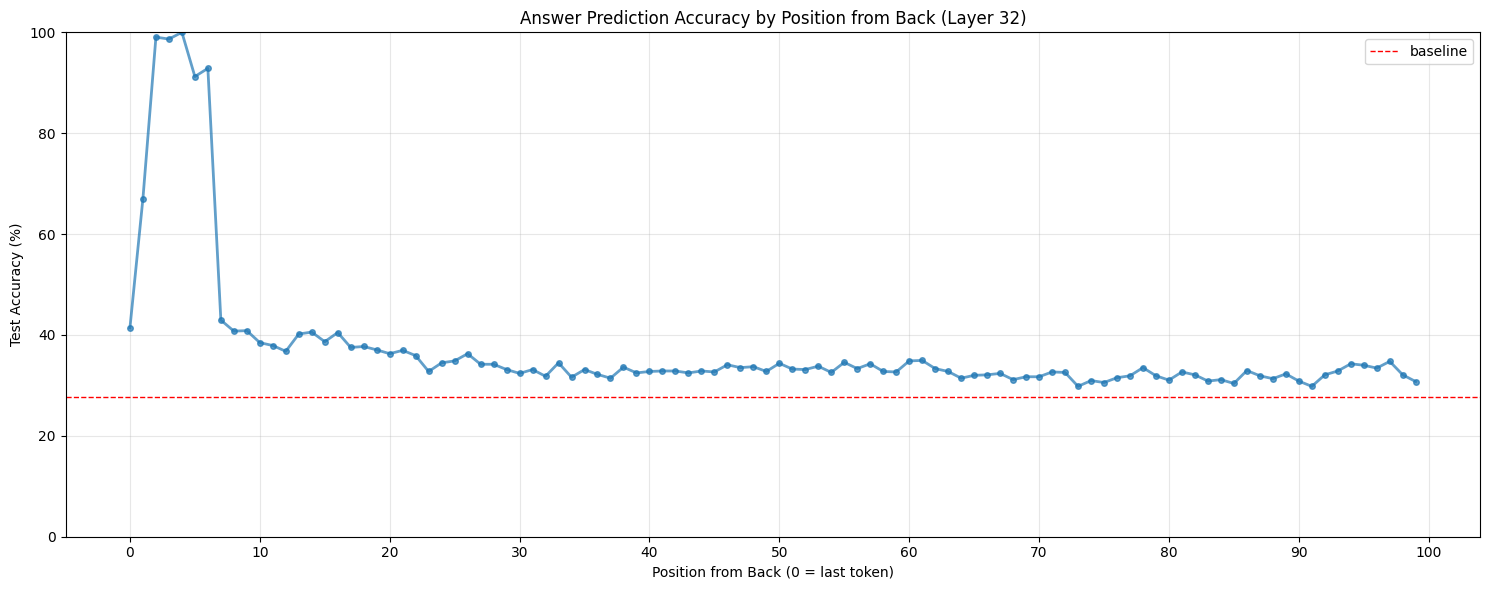

Layer 32 Position Sweep Summary:
  Total positions tested: 100
  Best accuracy: 100.00%
  Best position: 4
  Mean accuracy: 37.26%
  Std accuracy: 14.31%


In [3]:
def load_position_sweep(results_path):
    records = []
    if os.path.exists(results_path):
        with open(results_path, 'r') as f:
            for line in f:
                rec = json.loads(line.strip())
                if rec.get('epoch') == 'best':
                    # Extract bin index from run_name like "bin_0_experiment"
                    m = re.search(r'bin_(\d+)_experiment', rec.get('run_name', ''))
                    if m:
                        bin_idx = int(m.group(1))
                        records.append({'position': bin_idx, 'test_acc': rec.get('test_acc')})
    df = pd.DataFrame(records)
    if not df.empty:
        return df.sort_values('position')
    else:
        return df

LAYER32_PATH = '/mnt/polished-lake/home/sidboppana/disentangling-computation-from-cot/probing/results/last_100_positions_layer32/results.jsonl'
layer32_df = load_position_sweep(LAYER32_PATH)

plt.figure(figsize=(15, 6))
if not layer32_df.empty:
    plt.plot(layer32_df['position'], layer32_df['test_acc'], marker='o', linewidth=2, markersize=4, alpha=0.7)
    plt.title('Answer Prediction Accuracy by Position from Back (Layer 32)')
    plt.xlabel('Position from Back (0 = last token)')
    plt.ylabel('Test Accuracy (%)')
    plt.grid(True, alpha=0.3)
    plt.xticks(range(0, 101, 10))
    plt.ylim(0, 100)
    plt.axhline(y=27.8, color='red', linestyle='--', linewidth=1, label='baseline')
    
    # Highlight key positions
    
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"Layer 32 Position Sweep Summary:")
    print(f"  Total positions tested: {len(layer32_df)}")
    print(f"  Best accuracy: {layer32_df['test_acc'].max():.2f}%")
    print(f"  Best position: {layer32_df.loc[layer32_df['test_acc'].idxmax(), 'position']}")
    print(f"  Mean accuracy: {layer32_df['test_acc'].mean():.2f}%")
    print(f"  Std accuracy: {layer32_df['test_acc'].std():.2f}%")

else:
    print("No layer 32 position sweep results found. Make sure the experiment has completed.")

# Last Layer Positions Binned by 1% - MLP

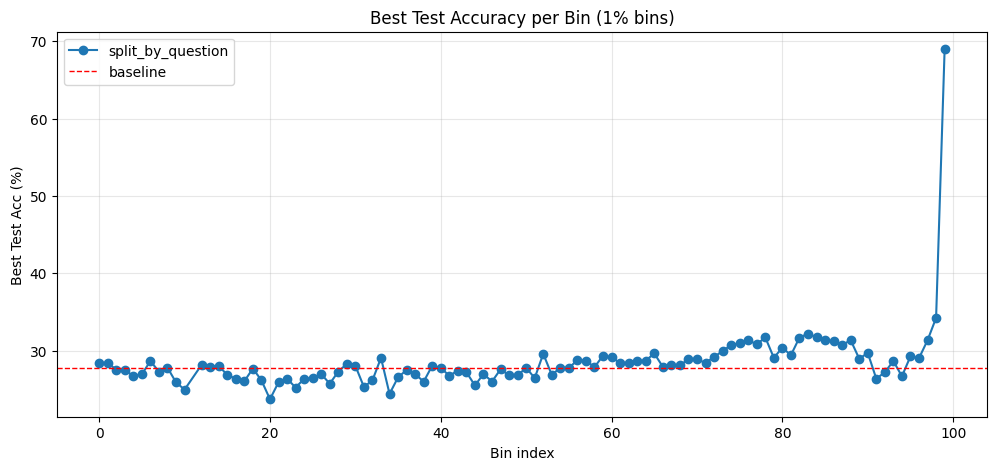

In [9]:
# Paths
BASE = Path('..') / 'results'
Q_PATH = BASE / 'mlp_percent_sweep/' / 'results.jsonl'

# Helper to load best per bin
BIN_RE = re.compile(r"bin_(\d+)_experiment")

def load_best(path: Path) -> pd.DataFrame:
    records = []
    if not path.exists():
        return pd.DataFrame(columns=['bin_idx', 'test_acc'])
    with open(path, 'r') as f:
        for line in f:
            try:
                rec = json.loads(line)
            except json.JSONDecodeError:
                continue
            if str(rec.get('epoch')) != 'best':
                continue
            run = rec.get('run_name', '')
            m = BIN_RE.search(run)
            if not m:
                continue
            bin_idx = int(m.group(1))
            records.append({'bin_idx': bin_idx, 'test_acc': rec.get('test_acc')})
    df = pd.DataFrame(records)
    return df.sort_values('bin_idx')

# Load
q_df = load_best(Q_PATH)

# Plot
plt.figure(figsize=(12, 5))
if not q_df.empty:
    plt.plot(q_df['bin_idx'], q_df['test_acc'], marker='o', label='split_by_question')
# Baseline line
plt.axhline(y=27.8, color='red', linestyle='--', linewidth=1, label='baseline')
plt.title('Best Test Accuracy per Bin (1% bins)')
plt.xlabel('Bin index')
plt.ylabel('Best Test Acc (%)')
plt.grid(True, alpha=0.3)

plt.legend()
plt.show()


# Linear vs. MLP Last 1k tokens

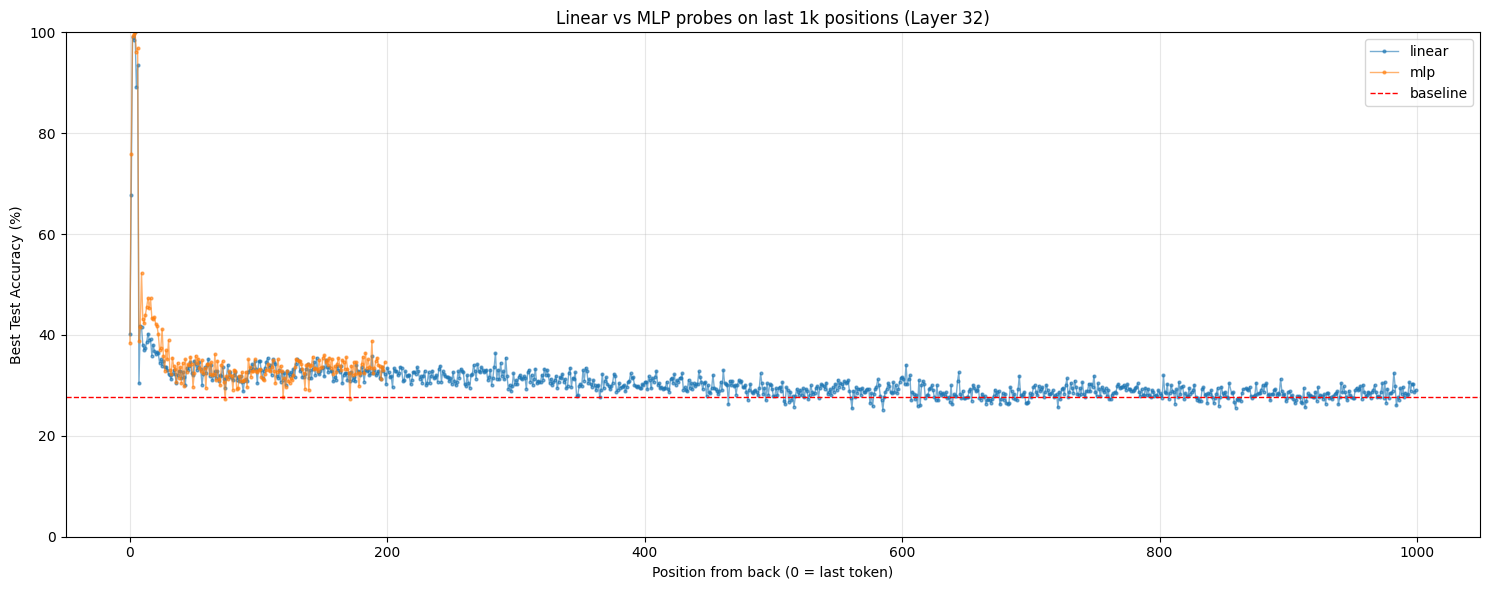

Linear: positions=998, best=100.00 at pos 4
MLP: positions=199, best=100.00 at pos 4


In [4]:
LINEAR_PATH = '/mnt/polished-lake/home/sidboppana/disentangling-computation-from-cot/probing/results/linear_last_1k_positions/results.jsonl'
MLP_PATH = '/mnt/polished-lake/home/sidboppana/disentangling-computation-from-cot/probing/results/mlp_last_1k_positions/results.jsonl'

BIN_RE = re.compile(r'bin_(\d+)_experiment')

def load_best_by_position(results_path):
    records = []
    if os.path.exists(results_path):
        with open(results_path, 'r') as f:
            for line in f:
                try:
                    rec = json.loads(line.strip())
                except json.JSONDecodeError:
                    continue
                if str(rec.get('epoch')) != 'best':
                    continue
                m = BIN_RE.search(rec.get('run_name', ''))
                if not m:
                    continue
                pos = int(m.group(1))
                acc = rec.get('test_acc')
                records.append({'position': pos, 'test_acc': acc})
    df = pd.DataFrame(records)
    return df.sort_values('position') if not df.empty else df

linear_df = load_best_by_position(LINEAR_PATH)
mlp_df = load_best_by_position(MLP_PATH)

plt.figure(figsize=(15, 6))
plotted_any = False
if not linear_df.empty:
    plt.plot(linear_df['position'], linear_df['test_acc'], label='linear', linewidth=1, markersize=2, marker='o', alpha=0.6)
    plotted_any = True
if not mlp_df.empty:
    plt.plot(mlp_df['position'], mlp_df['test_acc'], label='mlp', linewidth=1, markersize=2, marker='o', alpha=0.6)
    plotted_any = True

if plotted_any:
    plt.title('Linear vs MLP probes on last 1k positions (Layer 32)')
    plt.xlabel('Position from back (0 = last token)')
    plt.ylabel('Best Test Accuracy (%)')
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 100)
    plt.axhline(y=27.8, color='red', linestyle='--', linewidth=1, label='baseline')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Print quick summaries
    if not linear_df.empty:
        print(f"Linear: positions={len(linear_df)}, best={linear_df['test_acc'].max():.2f} at pos {linear_df.loc[linear_df['test_acc'].idxmax(), 'position']}")
    if not mlp_df.empty:
        print(f"MLP: positions={len(mlp_df)}, best={mlp_df['test_acc'].max():.2f} at pos {mlp_df.loc[mlp_df['test_acc'].idxmax(), 'position']}")
else:
    print('No results found for linear and/or mlp last 1k positions.')

# Regular vs. Distilled — Linear probes on last 1k positions


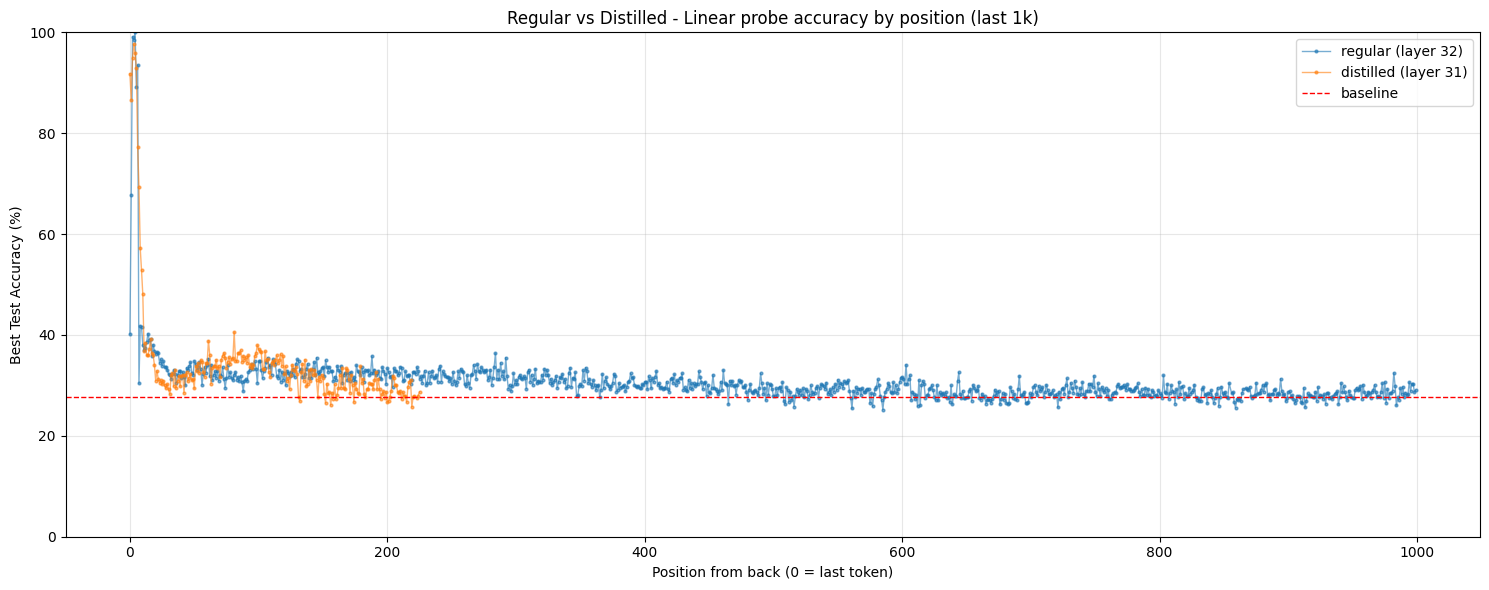

Regular: positions=998, best=100.00 at pos 4
Distilled: positions=225, best=97.69 at pos 3


In [6]:
# Compare regular vs. distilled (linear, last 1k positions)
import json
import re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import os

REGULAR_PATH = '/mnt/polished-lake/home/sidboppana/disentangling-computation-from-cot/probing/results/linear_last_1k_positions/results.jsonl'
DISTILL_PATH = '/mnt/polished-lake/home/sidboppana/disentangling-computation-from-cot/probing/results/linear_last_1k_positions_distill_layer31/results.jsonl'

BIN_RE = re.compile(r'bin_(\d+)_experiment')

def load_best_by_position(path):
    records = []
    if os.path.exists(path):
        with open(path, 'r') as f:
            for line in f:
                try:
                    rec = json.loads(line.strip())
                except json.JSONDecodeError:
                    continue
                if str(rec.get('epoch')) != 'best':
                    continue
                m = BIN_RE.search(rec.get('run_name', ''))
                if not m:
                    continue
                pos = int(m.group(1))
                acc = rec.get('test_acc')
                records.append({'position': pos, 'test_acc': acc})
    df = pd.DataFrame(records)
    return df.sort_values('position') if not df.empty else df

reg_df = load_best_by_position(REGULAR_PATH)
dist_df = load_best_by_position(DISTILL_PATH)

plt.figure(figsize=(15, 6))
plotted_any = False
if not reg_df.empty:
    plt.plot(reg_df['position'], reg_df['test_acc'], label='regular (layer 32)', linewidth=1, markersize=2, marker='o', alpha=0.6)
    plotted_any = True
if not dist_df.empty:
    plt.plot(dist_df['position'], dist_df['test_acc'], label='distilled (layer 31)', linewidth=1, markersize=2, marker='o', alpha=0.6)
    plotted_any = True

if plotted_any:
    plt.title('Regular vs Distilled - Linear probe accuracy by position (last 1k)')
    plt.xlabel('Position from back (0 = last token)')
    plt.ylabel('Best Test Accuracy (%)')
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 100)
    plt.axhline(y=27.8, color='red', linestyle='--', linewidth=1, label='baseline')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Print quick summaries
    if not reg_df.empty:
        print(f"Regular: positions={len(reg_df)}, best={reg_df['test_acc'].max():.2f} at pos {reg_df.loc[reg_df['test_acc'].idxmax(), 'position']}")
    if not dist_df.empty:
        print(f"Distilled: positions={len(dist_df)}, best={dist_df['test_acc'].max():.2f} at pos {dist_df.loc[dist_df['test_acc'].idxmax(), 'position']}")
else:
    print('No results found for regular and/or distilled last 1k positions.')
